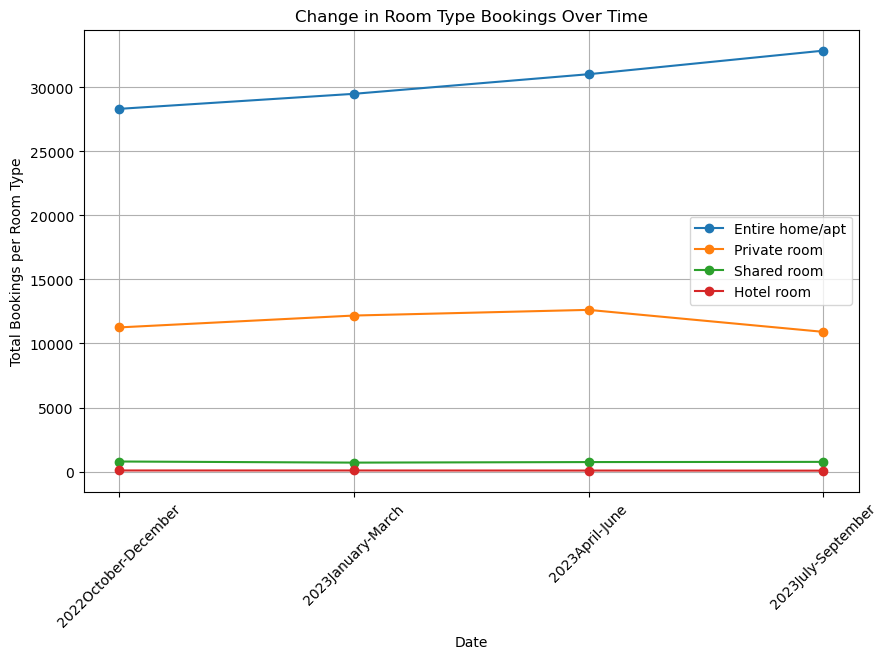

Total Bookings for Each Room Type Over Time:
room_type             Entire home/apt  Private room  Shared room  Hotel room
2022October-December            28317         11253          784          84
2023January-March               29491         12180          697          83
2023April-June                  31023         12623          740          78
2023July-September              32863         10906          755          70


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Define data path
file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

# Initialize DataFrame to store the total count of room types
room_type_trends = pd.DataFrame()

# Iterate through all datasets
for date, file_path in file_paths.items():
    # Read data
    df = pd.read_csv(file_path)
    
    # Count the total number of bookings for each room type
    room_type_counts = df['room_type'].value_counts()
    
    # Store in DataFrame with the index set as the data
    room_type_trends[date] = room_type_counts

# Transpose data to make it suitable for plotting
room_type_trends = room_type_trends.T.fillna(0)

# Plot chart
plt.figure(figsize=(10, 6))
for room_type in room_type_trends.columns:
    plt.plot(room_type_trends.index, room_type_trends[room_type], marker='o', label=room_type)

plt.xlabel("Date")
plt.ylabel("Total Bookings per Room Type")
plt.title("Change in Room Type Bookings Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Diaplay data information
print("Total Bookings for Each Room Type Over Time:")
print(room_type_trends)


<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
C:\Users\jiani\AppData\Local\Temp\ipykernel_24004\1036215382.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


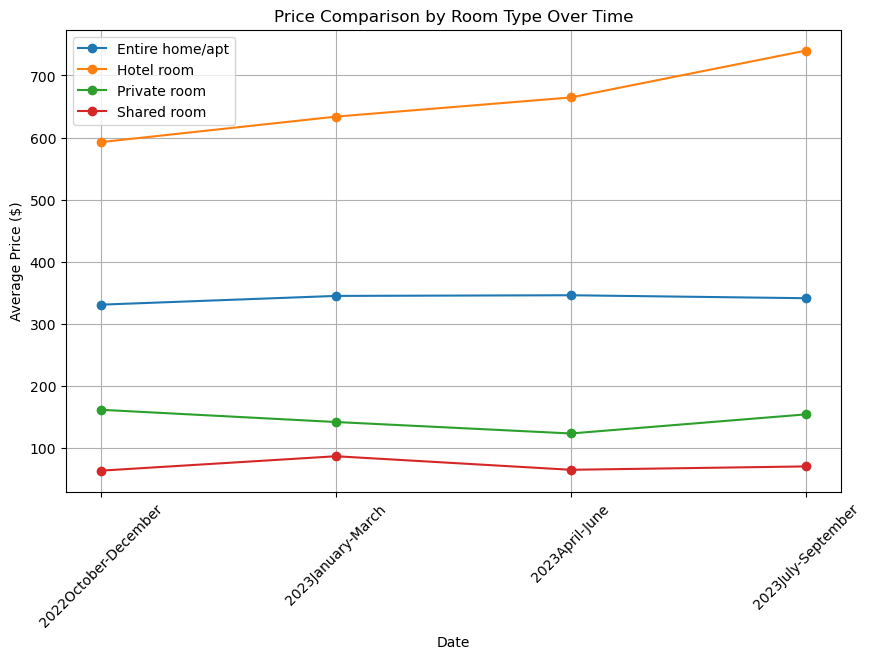

Average Price by Room Type Over Time:
room_type             Entire home/apt  Hotel room  Private room  Shared room
2022October-December       331.171450  592.773810    161.967291    64.017857
2023January-March          345.241565  633.795181    142.274548    87.205165
2023April-June             346.300519  664.653846    123.846154    65.404054
2023July-September         341.532209  739.957143    154.568861    70.817219


In [2]:
# Initialize DataFrame to store room type price information
price_trends = pd.DataFrame()

# Iterate through all datasets
for date, file_path in file_paths.items():
    df = pd.read_csv(file_path)
    
    # Process the price column by removing the $ symbol and converting it to float
    df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
    
    # Calculate the average price for each room type
    avg_price_per_room = df.groupby('room_type')['price'].mean()
    
    # Store in DataFrame with the index set as the date
    price_trends[date] = avg_price_per_room

# Transpose data to make it suitable for plotting
price_trends = price_trends.T.fillna(0)

# Plot line chart
plt.figure(figsize=(10, 6))
for room_type in price_trends.columns:
    plt.plot(price_trends.index, price_trends[room_type], marker='o', label=room_type)

plt.xlabel("Date")
plt.ylabel("Average Price ($)")
plt.title("Price Comparison by Room Type Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Diaplay data information
print("Average Price by Room Type Over Time:")
print(price_trends)

<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
C:\Users\jiani\AppData\Local\Temp\ipykernel_24004\2365352579.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


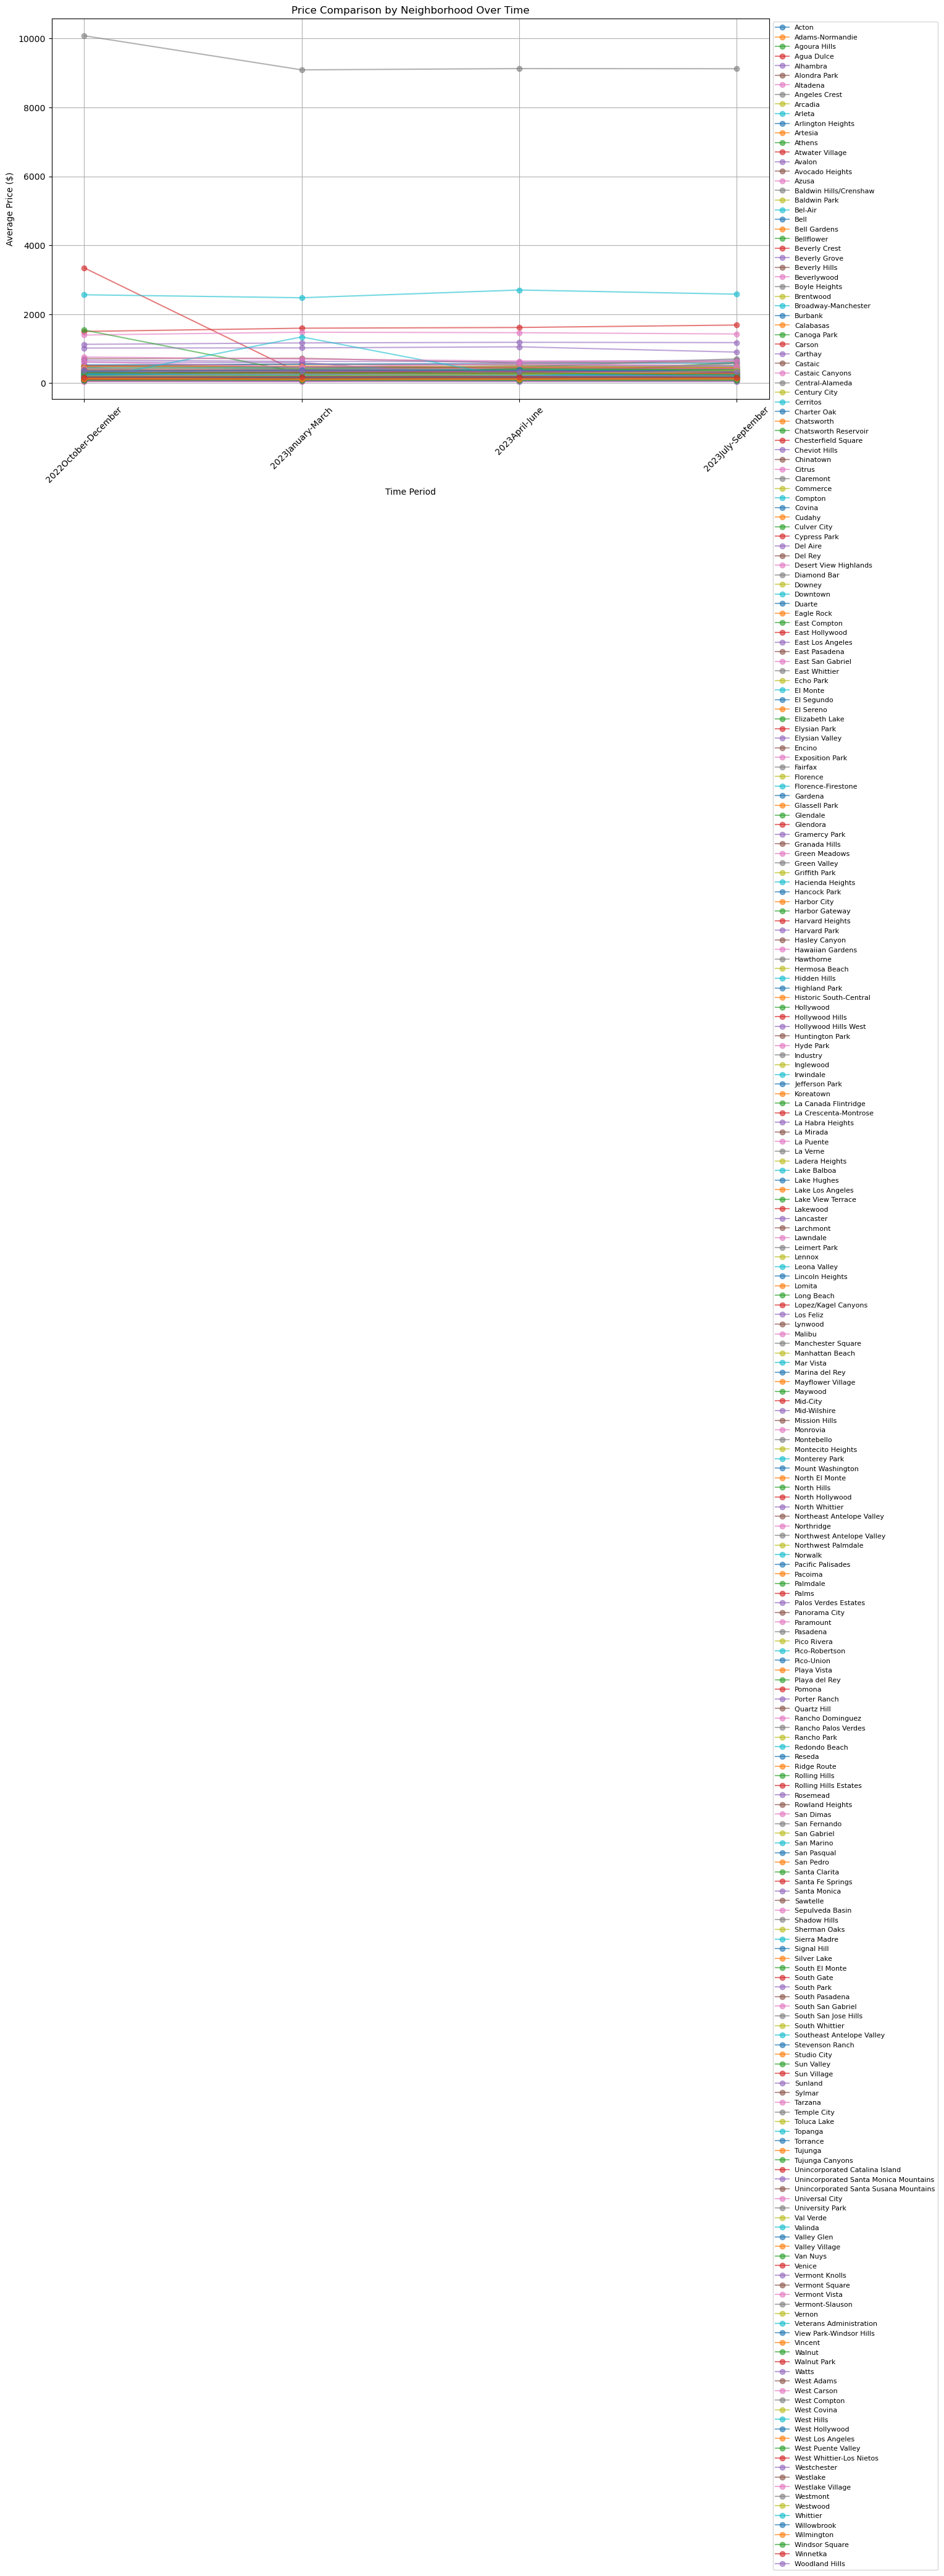

In [9]:
# Initialize DataFrame to store the average proce for each neighborhood_cleansed
neighborhood_price_trends = pd.DataFrame()

# Iterate through all datasets
for period, file_path in file_paths.items():
    df = pd.read_csv(file_path)
    
    # Process the price column by removing the $ symbol and converting it to float
    df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
    
    # Calculate the average price for each neighborhood_cleansed
    avg_price_per_neighborhood = df.groupby('neighbourhood_cleansed')['price'].mean()
    
    # Store in DataFrame with the index set as the time period
    neighborhood_price_trends[period] = avg_price_per_neighborhood

# Transpose data to make it suitable for plotting
neighborhood_price_trends = neighborhood_price_trends.T.fillna(0)

# Plot line chart(including all neighborhoods)
plt.figure(figsize=(15, 8))
for neighborhood in neighborhood_price_trends.columns:
    plt.plot(neighborhood_price_trends.index, neighborhood_price_trends[neighborhood], marker='o', label=neighborhood, alpha=0.6)

plt.xlabel("Time Period")
plt.ylabel("Average Price ($)")
plt.title("Price Comparison by Neighborhood Over Time")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1, fontsize=8)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
C:\Users\jiani\AppData\Local\Temp\ipykernel_24004\2517248138.py:8: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


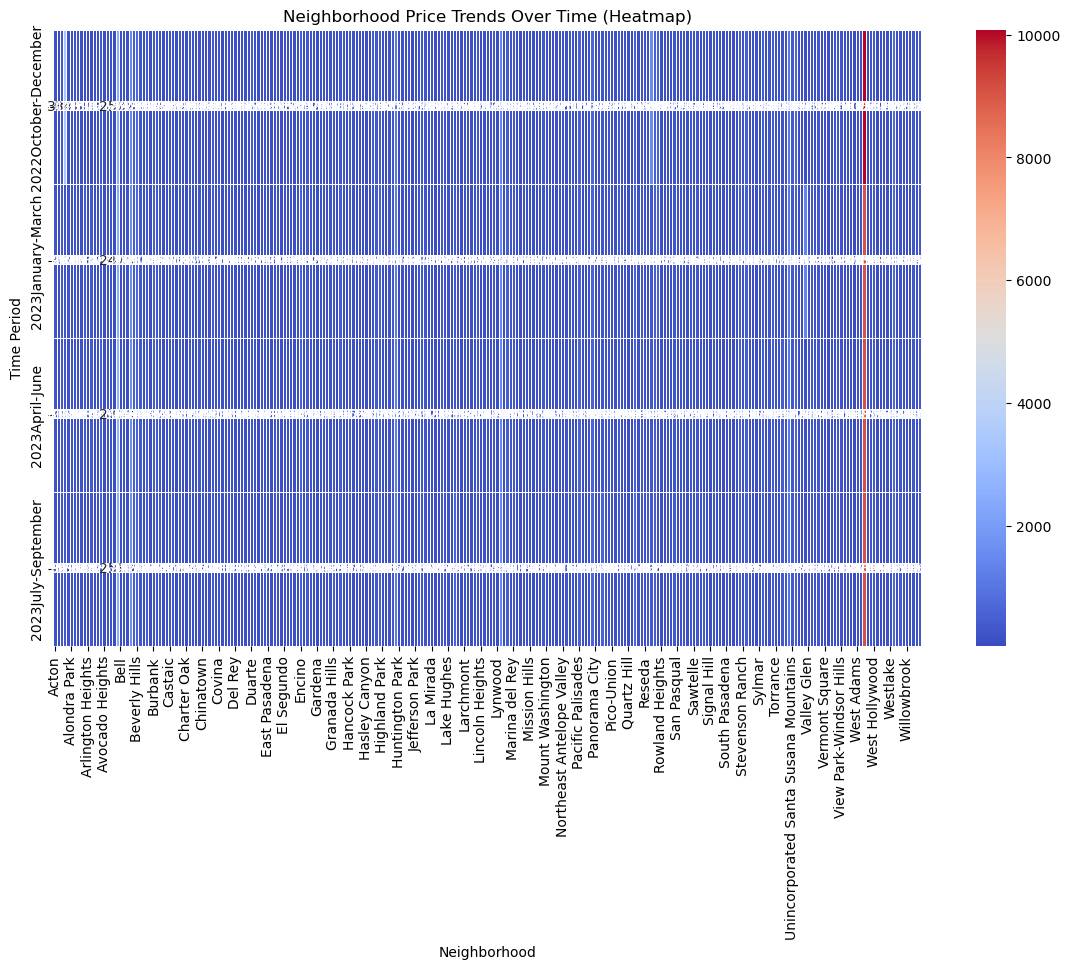

In [11]:
import seaborn as sns
# Initializa DataFrame
neighborhood_price_trends = pd.DataFrame()

# Iterate through the dataset
for period, file_path in file_paths.items():
    df = pd.read_csv(file_path)
    df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
    avg_price_per_neighborhood = df.groupby('neighbourhood_cleansed')['price'].mean()
    neighborhood_price_trends[period] = avg_price_per_neighborhood

# Transpose data
neighborhood_price_trends = neighborhood_price_trends.T.fillna(0)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(neighborhood_price_trends, cmap="coolwarm", annot=True, fmt=".0f", linewidths=0.5)

plt.xlabel("Neighborhood")
plt.ylabel("Time Period")
plt.title("Neighborhood Price Trends Over Time (Heatmap)")
plt.xticks(rotation=90)
plt.show()

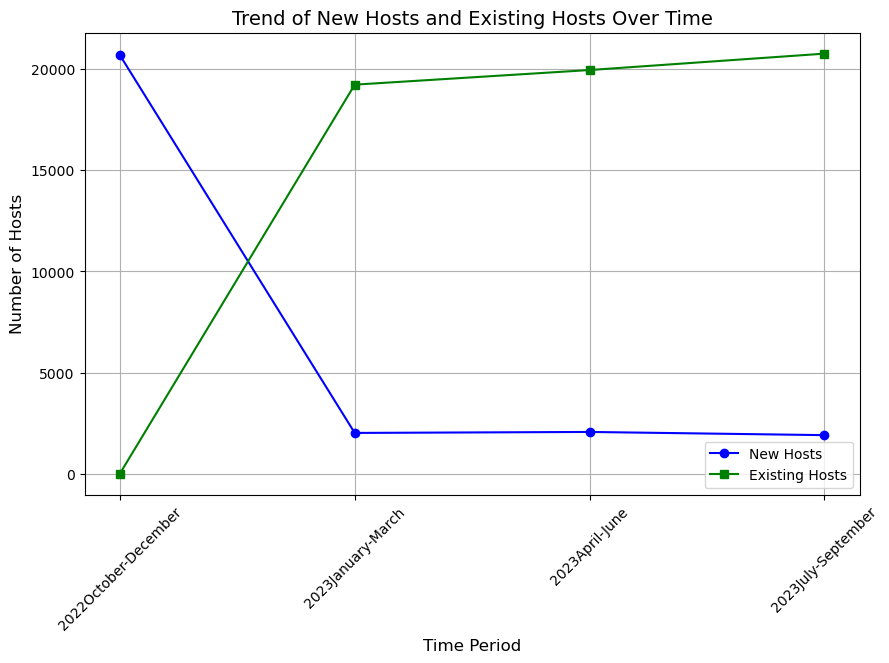

In [13]:
# Initialize DataFrame to store Host data
host_trend = pd.DataFrame(columns=['New Hosts', 'Existing Hosts'])

# Record previously encountered host_id
existing_host_ids = set()

# Read all datasets and calculate new hosts and existing hosts
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # ensure host_id is numeric type
        df['host_id'] = df['host_id'].astype(str)

        # Calculate host_id for the current time period
        current_hosts = set(df['host_id'].unique())

        # Calculate New Hosts
        new_hosts = current_hosts - existing_host_ids

        # Calculate Existing Hosts
        existing_hosts = current_hosts & existing_host_ids

        # Record the number of New Hosts and Existing Hosts
        host_trend.loc[period] = [len(new_hosts), len(existing_hosts)]

        # Update the previously encountered host_id
        existing_host_ids.update(current_hosts)

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Plot line chart
plt.figure(figsize=(10, 6))
plt.plot(host_trend.index, host_trend['New Hosts'], marker='o', linestyle='-', label='New Hosts', color='blue')
plt.plot(host_trend.index, host_trend['Existing Hosts'], marker='s', linestyle='-', label='Existing Hosts', color='green')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Hosts", fontsize=12)
plt.title("Trend of New Hosts and Existing Hosts Over Time", fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [14]:
# Initialize DataFrame to store the number of New Hosts and Existing Hosts
host_trend = pd.DataFrame(columns=['New Hosts', 'Existing Hosts'])

# Record previously encountered host_id
existing_host_ids = set()

# Read all datasets and calculate New Hosts and Existing Hosts
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # Ensure host_id is in string format
        df['host_id'] = df['host_id'].astype(str)

        # Calculate host_id for the current time period
        current_hosts = set(df['host_id'].unique())

        # Calculate New Hosts
        new_hosts = current_hosts - existing_host_ids

        # Calculate Existing Hosts
        existing_hosts = current_hosts & existing_host_ids

        # Record the number of New Hosts and Existing Hosts
        host_trend.loc[period] = [len(new_hosts), len(existing_hosts)]

        # Update the previously encountered host_id
        existing_host_ids.update(current_hosts)

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Output calculation results
print("New Hosts vs Existing Hosts Count Over Time:")
print(host_trend)


New Hosts vs Existing Hosts Count Over Time:
                      New Hosts  Existing Hosts
2022October-December      20692               0
2023January-March          2013           19233
2023April-June             2062           19956
2023July-September         1904           20766


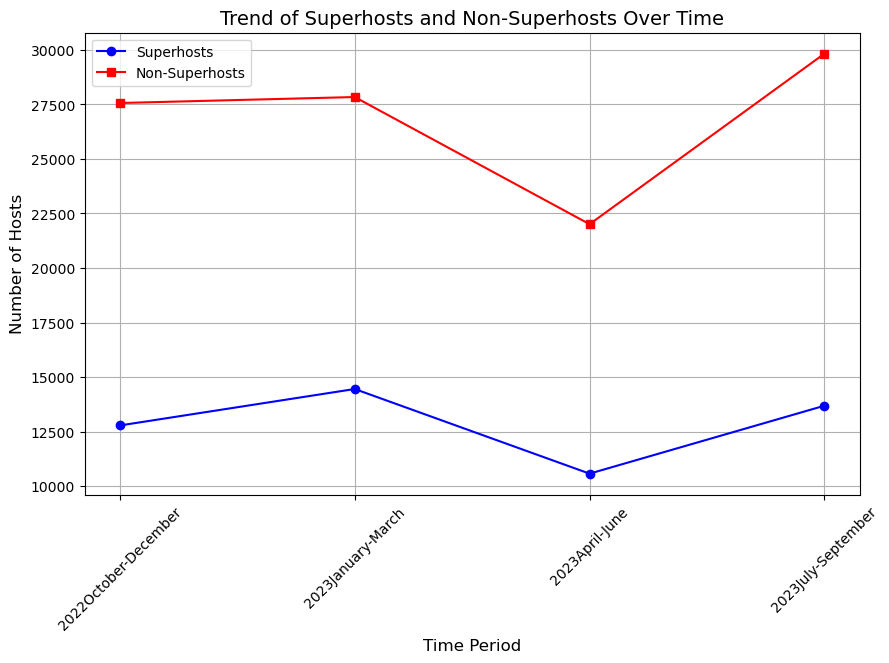

In [15]:
# Initialize DataFrame to store superhost data
superhost_trend = pd.DataFrame(columns=['Superhosts', 'Non-Superhosts'])

# Read all datasets and calculate superhosts and non-superhosts
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # Ensure the host_is_superhost column exists and convert it to a string
        if 'host_is_superhost' in df.columns:
            df['host_is_superhost'] = df['host_is_superhost'].astype(str)

            # Calculate the number of Superhosts
            num_superhosts = (df['host_is_superhost'] == 't').sum()

            # Calculate the number of Non-Superhosts
            num_non_superhosts = (df['host_is_superhost'] == 'f').sum()

            # Record data
            superhost_trend.loc[period] = [num_superhosts, num_non_superhosts]
        else:
            print(f"{file_path} does not contain the 'host_is_superhost' column")

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Plot line graph
plt.figure(figsize=(10, 6))
plt.plot(superhost_trend.index, superhost_trend['Superhosts'], marker='o', linestyle='-', label='Superhosts', color='blue')
plt.plot(superhost_trend.index, superhost_trend['Non-Superhosts'], marker='s', linestyle='-', label='Non-Superhosts', color='red')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Hosts", fontsize=12)
plt.title("Trend of Superhosts and Non-Superhosts Over Time", fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [16]:
# Initialize DataFrame to store the number of Superhosts and Non-Superhosts
superhost_trend = pd.DataFrame(columns=['Superhosts', 'Non-Superhosts'])

# Iterate through all datasets and calculate Superhosts and Non-Superhosts
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # Keep data related to host_is_superhost
        df['host_is_superhost'] = df['host_is_superhost'].astype(str).str.lower()

        # Calculate Superhosts and Non-Superhosts
        superhost_count = (df['host_is_superhost'] == 't').sum()
        non_superhost_count = (df['host_is_superhost'] == 'f').sum()

        # Store in DataFrame
        superhost_trend.loc[period] = [superhost_count, non_superhost_count]

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Output calculation results
print("Superhost vs Non-Superhost Count Over Time:")
print(superhost_trend)

Superhost vs Non-Superhost Count Over Time:
                      Superhosts  Non-Superhosts
2022October-December       12783           27564
2023January-March          14454           27838
2023April-June             10574           22009
2023July-September         13688           29827


Number of Listings Over Time:
                      Number of Listings
2022October-December               40438
2023January-March                  42451
2023April-June                     44464
2023July-September                 44594


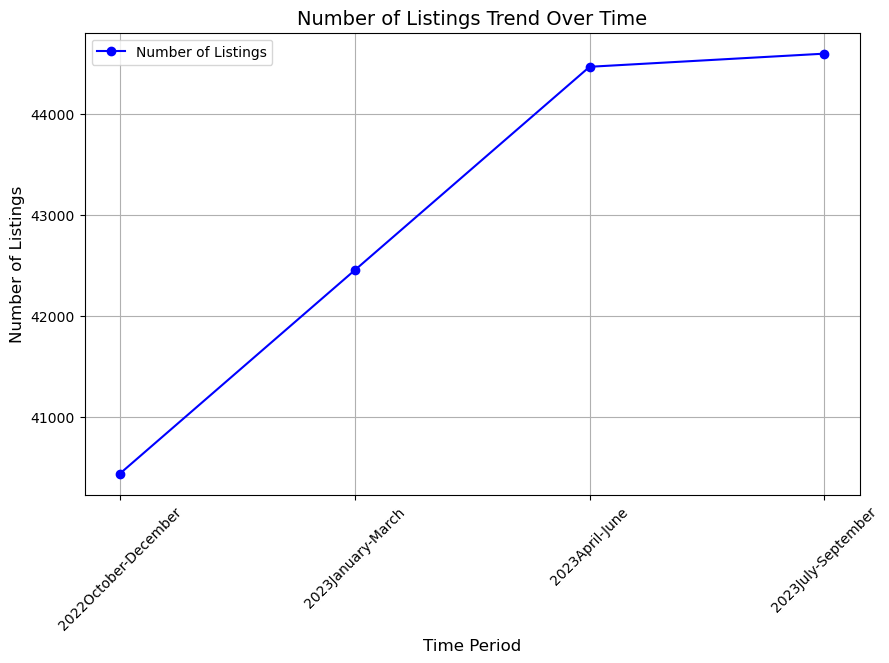

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

listings_trend = pd.DataFrame(columns=['Number of Listings'])

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        num_listings = len(df)

        listings_trend.loc[period] = [num_listings]

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Output calculate result
print("Number of Listings Over Time:")
print(listings_trend)

# Plot line graph
plt.figure(figsize=(10, 6))
plt.plot(listings_trend.index, listings_trend['Number of Listings'], marker='o', linestyle='-', color='b', label='Number of Listings')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.title("Number of Listings Trend Over Time", fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


Property Type with the highest growth: Entire home, Total Growth: 2431
Property Type Growth Over Time:
                           2022October-December  2023January-March  \
property_type                                                        
Entire rental unit                         9791              10390   
Entire home                                8697               9388   
Private room in home                       6051               6953   
Entire guesthouse                          2239               2330   
Entire condo                               2072               1953   
...                                         ...                ...   
Shared room in dome                           1                  1   
Lighthouse                                    1                  1   
Room in bed and breakfast                     1                  1   
Shared room in cabin                          1                  1   
Tipi                                          1          

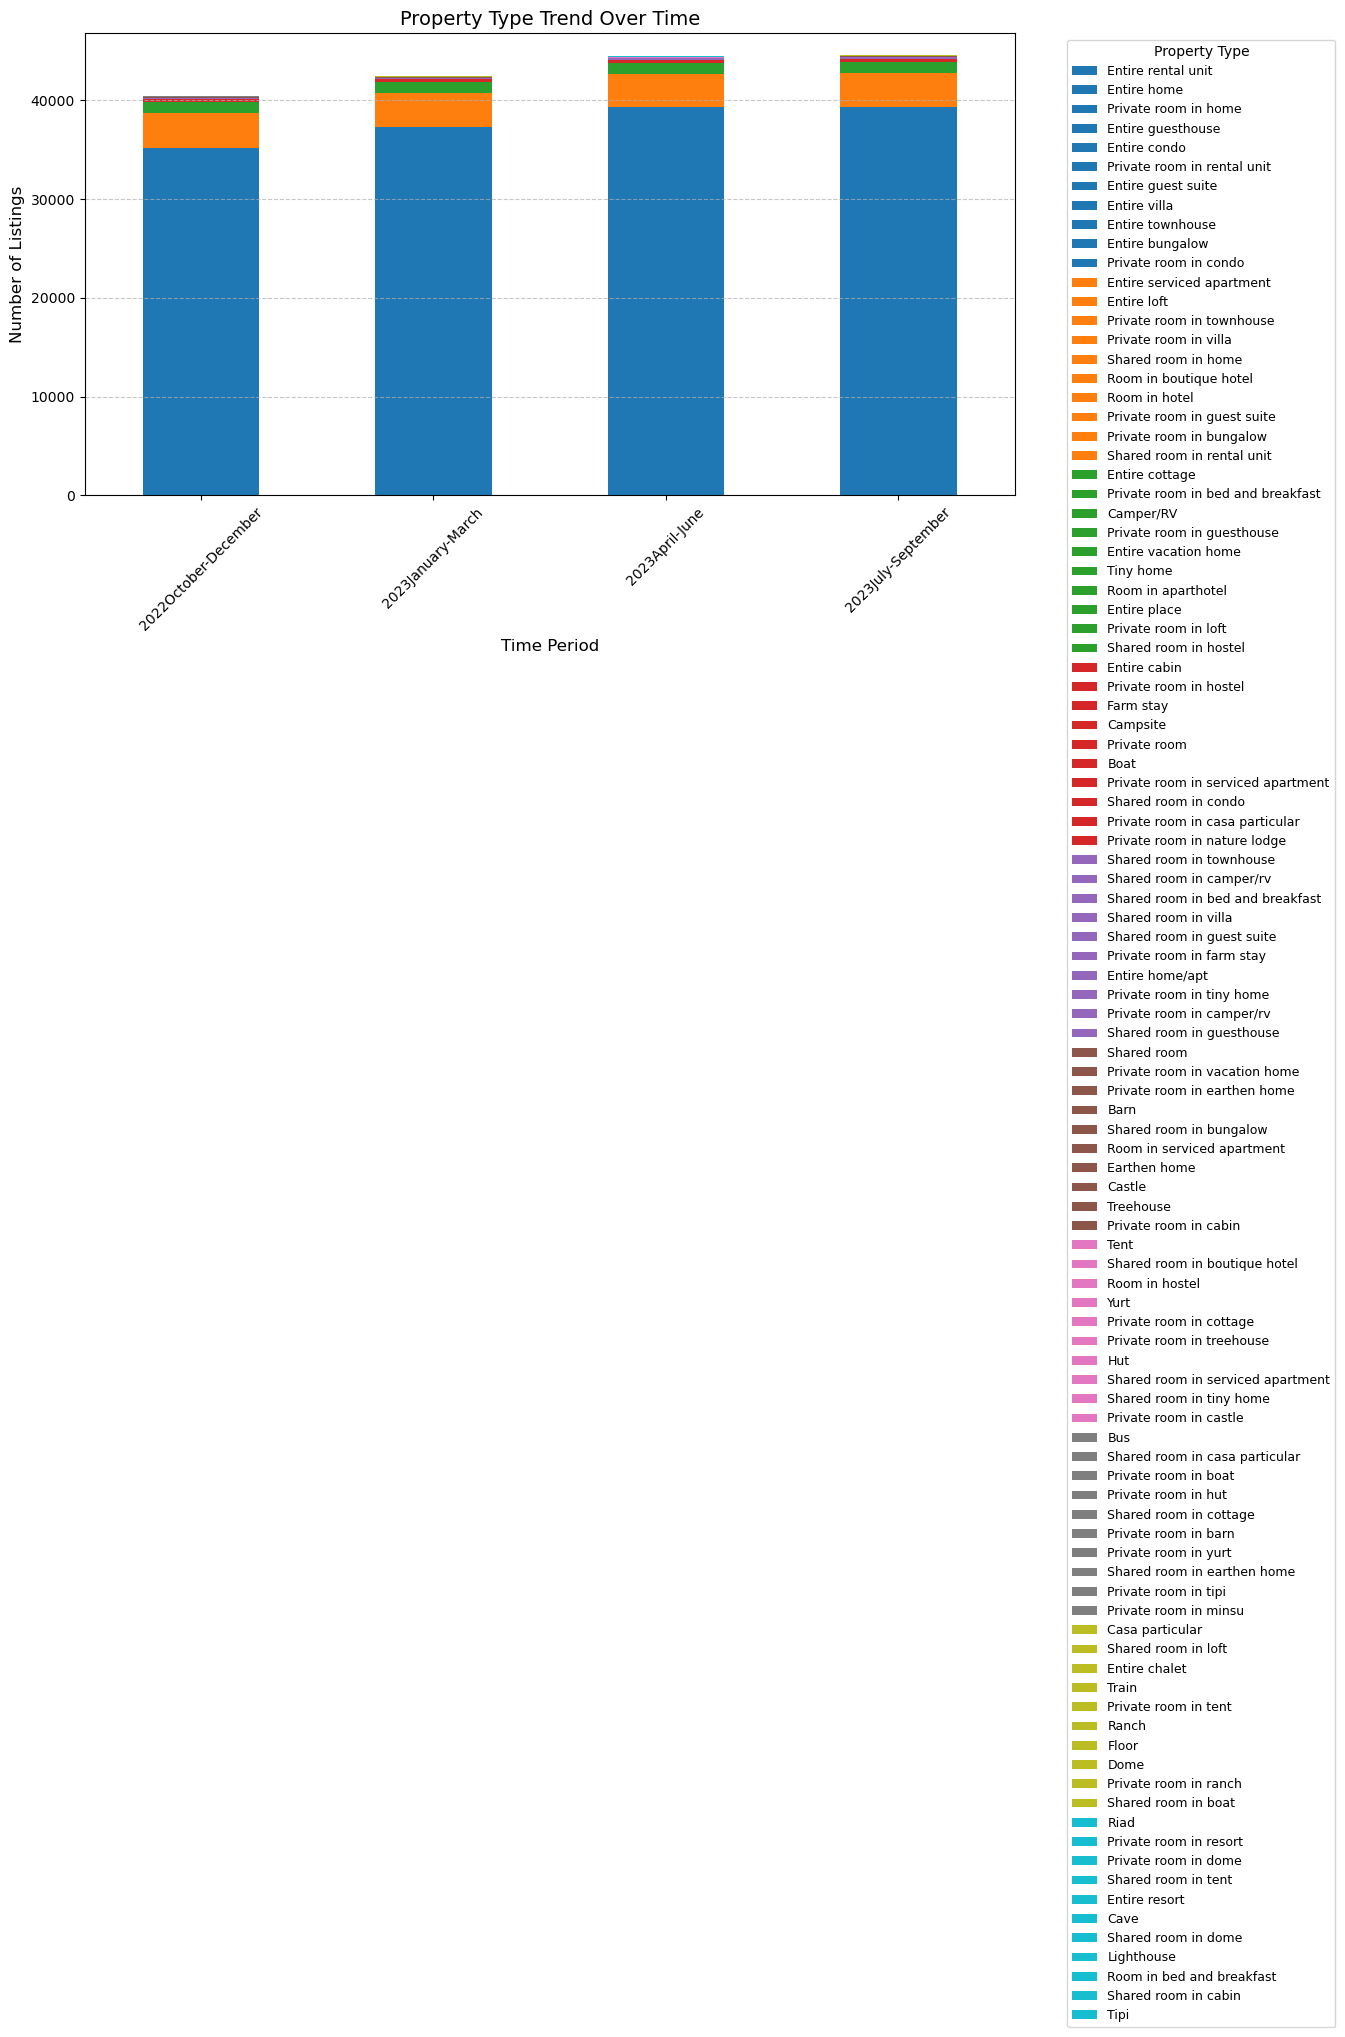

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

property_trend = pd.DataFrame()

# Calculate the number of Property Type
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # Count property_type
        property_count = df['property_type'].value_counts()

        property_trend[period] = property_count

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exist")

# Fill NaN values with 0
property_trend = property_trend.fillna(0).astype(int)

# Calculate growth amount
property_growth = property_trend.diff(axis=1).fillna(0).astype(int)

# Identify the property_type with the highest growth
top_growth = property_growth.sum(axis=1).idxmax()
print(f"Property Type with the highest growth: {top_growth}, Total Growth: {property_growth.sum(axis=1).max()}")

# Output calculation results
print("Property Type Growth Over Time:")
print(property_trend)

# Plot a bar chart showing growth trend of property types
property_trend.T.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.title("Property Type Trend Over Time", fontsize=14)
plt.legend(title="Property Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Property Type with the highest growth: Entire home, Total Growth: 2431
Property Type Growth Over Time:
                           2022October-December  2023January-March  \
property_type                                                        
Entire rental unit                         9791              10390   
Entire home                                8697               9388   
Private room in home                       6051               6953   
Entire guesthouse                          2239               2330   
Entire condo                               2072               1953   
...                                         ...                ...   
Shared room in dome                           1                  1   
Lighthouse                                    1                  1   
Room in bed and breakfast                     1                  1   
Shared room in cabin                          1                  1   
Tipi                                          1          

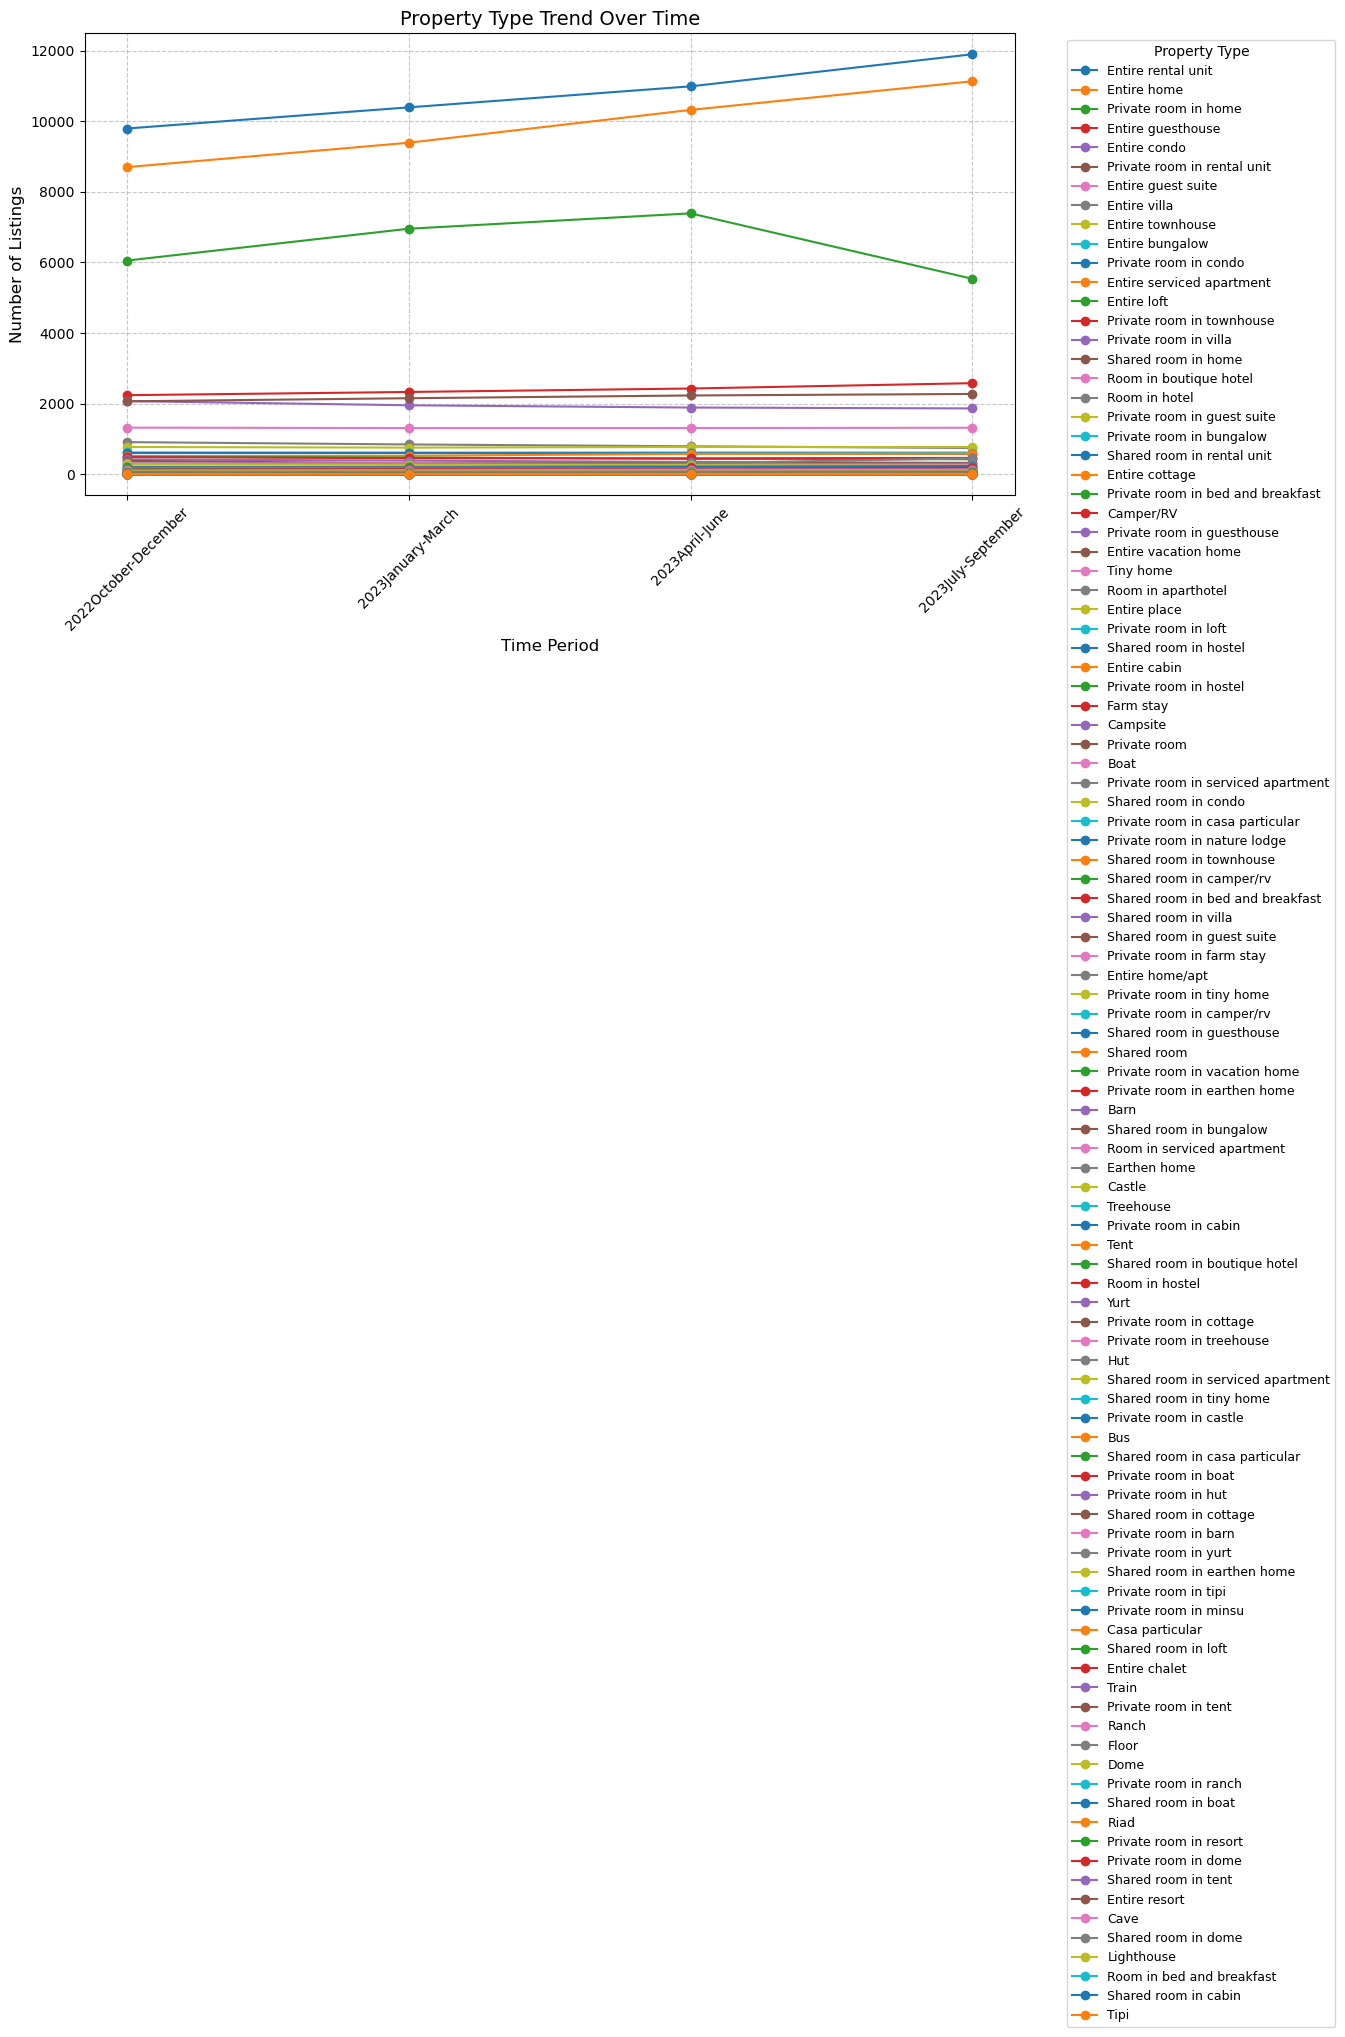

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

property_trend = pd.DataFrame()

# Count number of property type
for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        # Count the occurrences of each property_type
        property_count = df['property_type'].value_counts()

        property_trend[period] = property_count

    except FileNotFoundError:
        print(f"Skipping {file_path} because the file does not exists")

# Fill NaN values with 0
property_trend = property_trend.fillna(0).astype(int)

# Calculate growth amount
property_growth = property_trend.diff(axis=1).fillna(0).astype(int)

# Identify the property_type with the highest growth
top_growth = property_growth.sum(axis=1).idxmax()
print(f"Property Type with the highest growth: {top_growth}, Total Growth: {property_growth.sum(axis=1).max()}")

# Output the calculation results
print("Property Type Growth Over Time:")
print(property_trend)

# Plot the growth trend of Property Types
plt.figure(figsize=(12, 6))
for property_type in property_trend.index:
    plt.plot(property_trend.columns, property_trend.loc[property_type], marker='o', linestyle='-', label=property_type)

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.title("Property Type Trend Over Time", fontsize=14)
plt.legend(title="Property Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Long-term vs Short-term Landlords Average Price Over Time:
                      Long-term Average Price  Short-term Average Price
2022October-December               202.665546                290.640656
2023January-March                  206.971693                293.977293
2023April-June                     230.710418                285.648665
2023July-September                 241.607337                298.927420


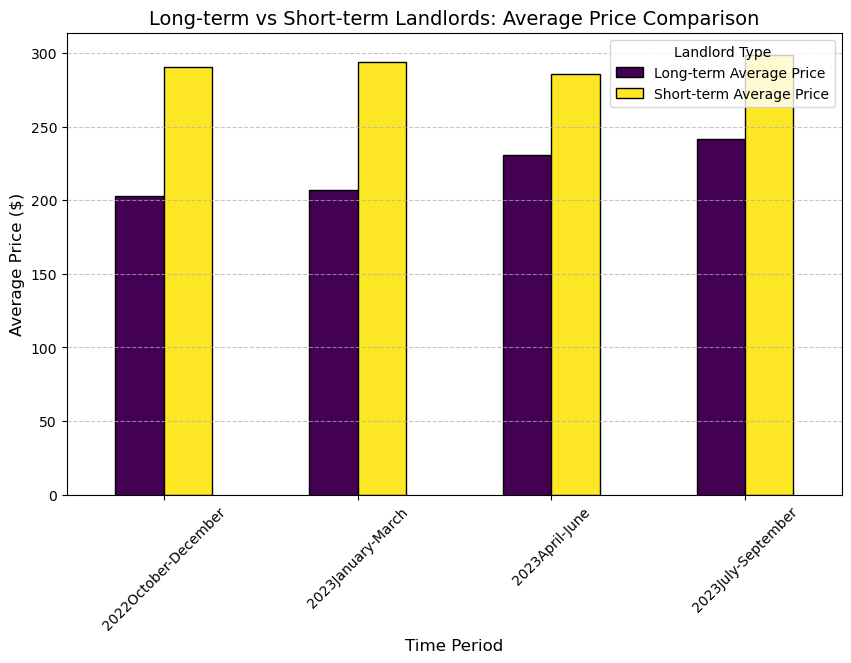

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

price_comparison = pd.DataFrame(columns=['Long-term Average Price', 'Short-term Average Price'])

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
        df['minimum_nights'] = df['minimum_nights'].astype(float)
        
        long_term = df[df['minimum_nights'] > 30]
        short_term = df[df['minimum_nights'] <= 30]

        # Calculate average price
        long_term_avg_price = long_term['price'].mean()
        short_term_avg_price = short_term['price'].mean()

        price_comparison.loc[period] = [long_term_avg_price, short_term_avg_price]

    except FileNotFoundError:
        print(f"Skipping {file_path} File not exist")

print("Long-term vs Short-term Landlords Average Price Over Time:")
print(price_comparison)

# Plot graph
price_comparison.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Long-term vs Short-term Landlords: Average Price Comparison", fontsize=14)
plt.legend(title="Landlord Type")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Long-term vs Short-term Rentals Count Over Time:
                      Long-term Rentals  Short-term Rentals
2022October-December               5144               35294
2023January-March                  5193               37258
2023April-June                     5356               39108
2023July-September                 5506               39088


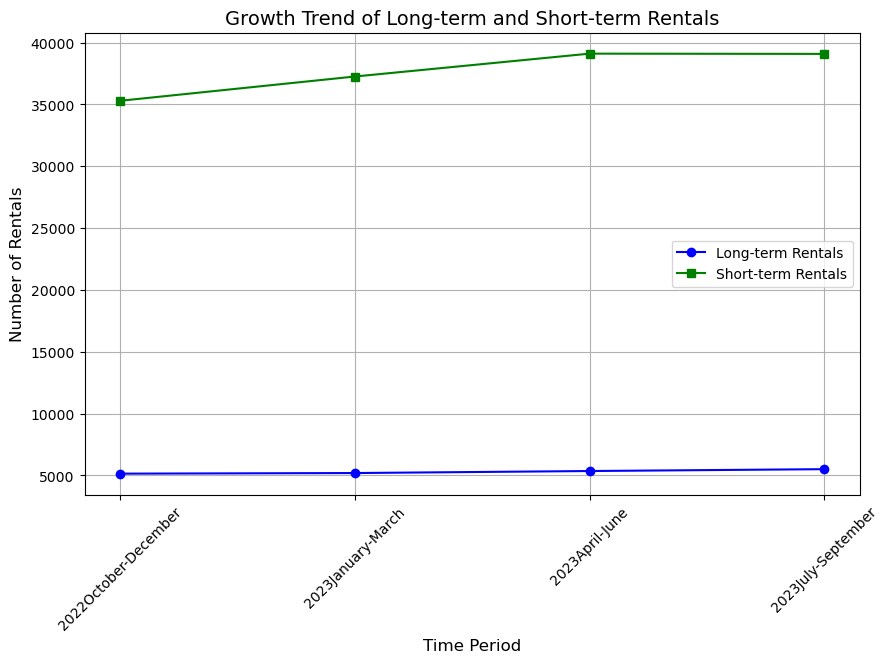

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

rental_trend = pd.DataFrame(columns=['Long-term Rentals', 'Short-term Rentals'])

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        df['minimum_nights'] = df['minimum_nights'].astype(float)
        long_term_count = (df['minimum_nights'] > 30).sum()
        short_term_count = (df['minimum_nights'] <= 30).sum()

        rental_trend.loc[period] = [long_term_count, short_term_count]

    except FileNotFoundError:
        print(f"Skipping{file_path}, File not exist")

print("Long-term vs Short-term Rentals Count Over Time:")
print(rental_trend)

plt.figure(figsize=(10, 6))
plt.plot(rental_trend.index, rental_trend['Long-term Rentals'], marker='o', linestyle='-', color='b', label='Long-term Rentals')
plt.plot(rental_trend.index, rental_trend['Short-term Rentals'], marker='s', linestyle='-', color='g', label='Short-term Rentals')

plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Number of Rentals", fontsize=12)
plt.title("Growth Trend of Long-term and Short-term Rentals", fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


Most Short-term Rentals: Sherman Oaks, Count: 6415
Most Long-term Rentals: Long Beach, Count: 2759
Neighbourhood Short-term vs Long-term Rentals Count:
                        2022October-December - Short-term  \
neighbourhood_cleansed                                      
Acton                                                  11   
Adams-Normandie                                        27   
Agoura Hills                                           49   
Agua Dulce                                             26   
Alhambra                                              452   
...                                                   ...   
Willowbrook                                            25   
Wilmington                                             15   
Windsor Square                                         26   
Winnetka                                               87   
Woodland Hills                                        383   

                        2022October-December - Long-te

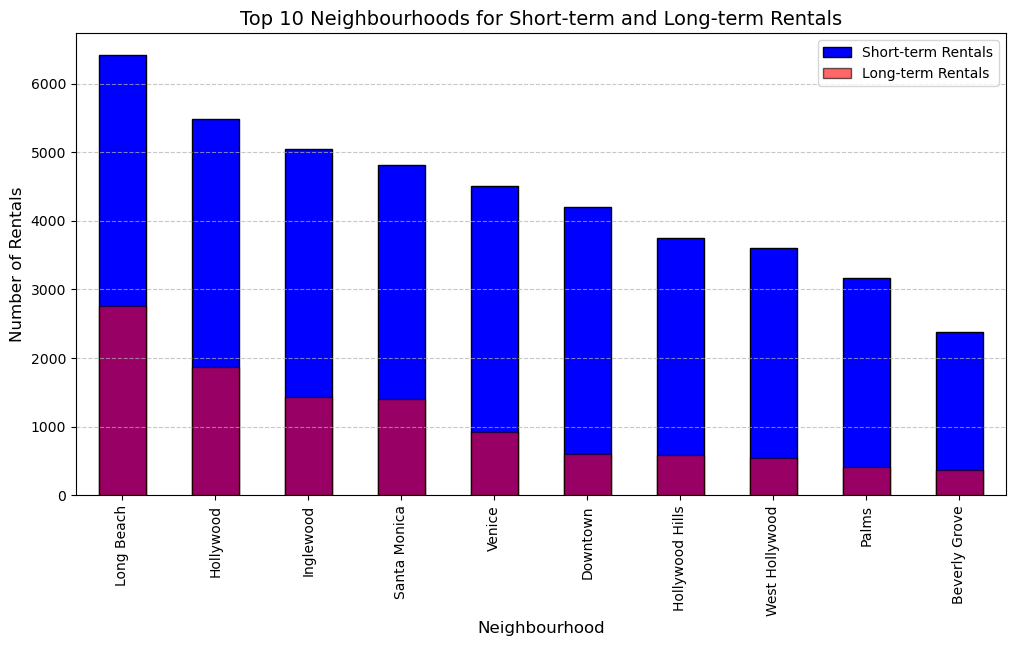

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

neighbourhood_counts = pd.DataFrame()

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)
        df['minimum_nights'] = df['minimum_nights'].astype(float)
        short_term = df[df['minimum_nights'] <= 30].groupby('neighbourhood_cleansed').size()
        long_term = df[df['minimum_nights'] > 30].groupby('neighbourhood_cleansed').size()
        
        neighbourhood_counts[period + " - Short-term"] = short_term
        neighbourhood_counts[period + " - Long-term"] = long_term

    except FileNotFoundError:
        print(f"Skipping {file_path}, File not exist")

neighbourhood_counts = neighbourhood_counts.fillna(0).astype(int)

most_short_term_area = neighbourhood_counts.filter(like="Short-term").sum(axis=1).idxmax()
most_long_term_area = neighbourhood_counts.filter(like="Long-term").sum(axis=1).idxmax()

print(f"Most Short-term Rentals: {most_short_term_area}, Count: {neighbourhood_counts.filter(like='Short-term').sum(axis=1).max()}")
print(f"Most Long-term Rentals: {most_long_term_area}, Count: {neighbourhood_counts.filter(like='Long-term').sum(axis=1).max()}")

print("Neighbourhood Short-term vs Long-term Rentals Count:")
print(neighbourhood_counts)

neighbourhood_counts.filter(like="Short-term").sum(axis=1).sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(12, 6), color='blue', edgecolor='black', label="Short-term Rentals")

neighbourhood_counts.filter(like="Long-term").sum(axis=1).sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(12, 6), color='red', edgecolor='black', alpha=0.6, label="Long-term Rentals")

plt.xlabel("Neighbourhood", fontsize=12)
plt.ylabel("Number of Rentals", fontsize=12)
plt.title("Top 10 Neighbourhoods for Short-term and Long-term Rentals", fontsize=14)
plt.legend()
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Top 10 Most Expensive Neighbourhoods (Average Price Across Time Periods):
neighbourhood_cleansed
West Compton                             9356.719444
Bel-Air                                  2579.191186
Beverly Crest                            1596.281641
Malibu                                   1438.690274
Hollywood Hills West                     1160.570526
Agua Dulce                               1063.151146
Unincorporated Santa Monica Mountains     996.144129
Westlake Village                          680.906319
Beverly Hills                             658.315145
Palos Verdes Estates                      643.776905
dtype: float64


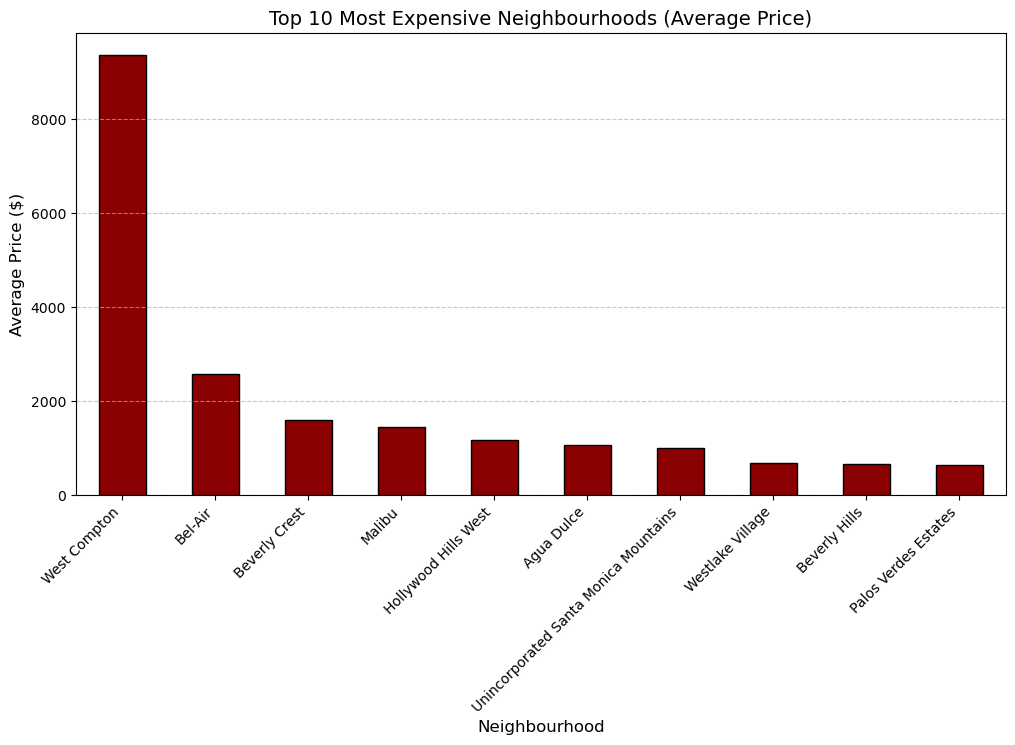

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

neighbourhood_prices = pd.DataFrame()

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

        avg_price_per_neighbourhood = df.groupby('neighbourhood_cleansed')['price'].mean()

        neighbourhood_prices[period] = avg_price_per_neighbourhood

    except FileNotFoundError:
        print(f"Skipping {file_path}，file not exist")

avg_neighbourhood_prices = neighbourhood_prices.mean(axis=1).sort_values(ascending=False)

top_10_expensive = avg_neighbourhood_prices.head(10)
print("Top 10 Most Expensive Neighbourhoods (Average Price Across Time Periods):")
print(top_10_expensive)

plt.figure(figsize=(12, 6))
top_10_expensive.plot(kind='bar', color='darkred', edgecolor='black')

plt.xlabel("Neighbourhood", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Top 10 Most Expensive Neighbourhoods (Average Price)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Top 10 Neighbourhoods with Highest Price Growth:
neighbourhood_cleansed
Lake View Terrace      454.000000
Pasadena               319.849069
Ridge Route            223.400000
Artesia                219.430478
Granada Hills          206.991341
Rancho Palos Verdes    196.797390
Canoga Park            192.130036
Beverly Crest          185.357367
Sherman Oaks           173.603528
Tujunga Canyons        168.574561
dtype: float64


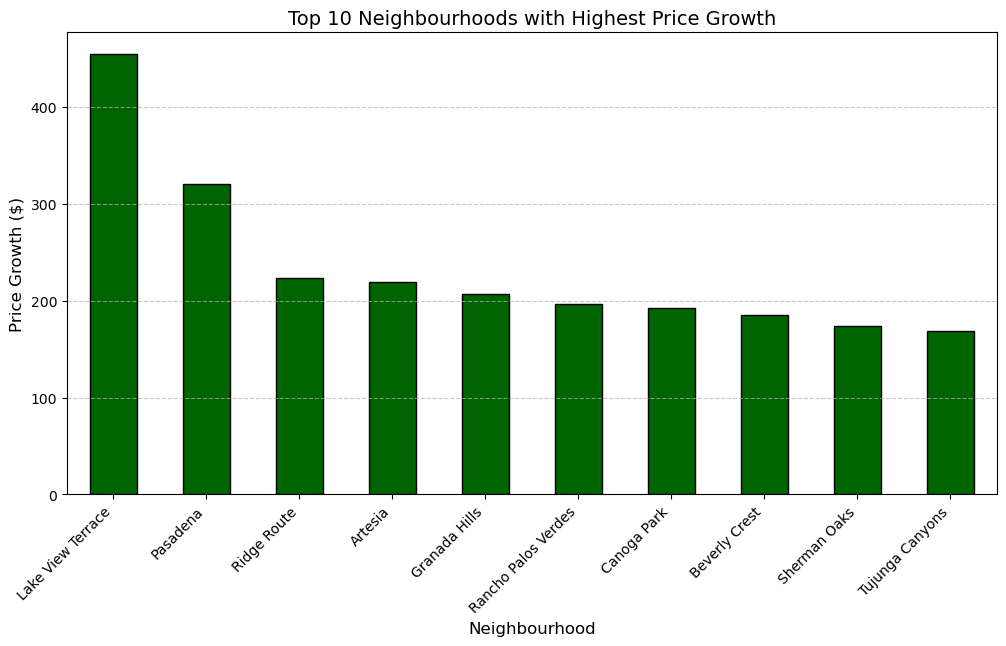

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "2022October-December": "2022.10-12.csv",
    "2023January-March": "2023.1-3.csv",
    "2023April-June": "2023.4-6.csv",
    "2023July-September": "2023.7-9.csv"
}

neighbourhood_prices = pd.DataFrame()

for period, file_path in file_paths.items():
    try:
        df = pd.read_csv(file_path)

        df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

        avg_price_per_neighbourhood = df.groupby('neighbourhood_cleansed')['price'].mean()

        neighbourhood_prices[period] = avg_price_per_neighbourhood

    except FileNotFoundError:
        print(f"Skipping {file_path}, File not exist")

neighbourhood_prices = neighbourhood_prices.fillna(0)
price_growth = (neighbourhood_prices.iloc[:, -1] - neighbourhood_prices.iloc[:, 0]).sort_values(ascending=False)

top_10_growth = price_growth.head(10)
print("Top 10 Neighbourhoods with Highest Price Growth:")
print(top_10_growth)

plt.figure(figsize=(12, 6))
top_10_growth.plot(kind='bar', color='darkgreen', edgecolor='black')

plt.xlabel("Neighbourhood", fontsize=12)
plt.ylabel("Price Growth ($)", fontsize=12)
plt.title("Top 10 Neighbourhoods with Highest Price Growth", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Top 10 Most Expensive Neighbourhoods (Average Price):
neighbourhood_cleansed
West Compton                             9124.500000
Bel-Air                                  2579.507042
Beverly Crest                            1683.168478
Malibu                                   1423.787879
Hollywood Hills West                     1173.033228
Unincorporated Santa Monica Mountains     897.995122
Rancho Palos Verdes                       703.687500
Palos Verdes Estates                      666.586207
Westlake Village                          633.384615
Beverly Hills                             622.380187
Name: price, dtype: float64


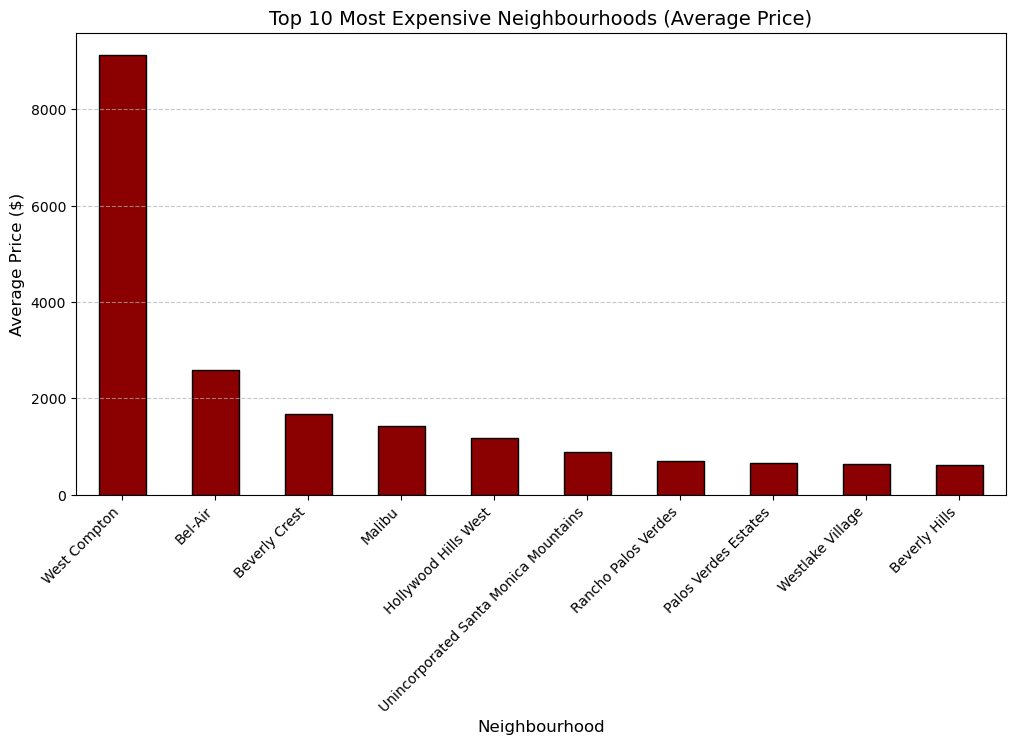

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

avg_price_per_neighbourhood = df.groupby('neighbourhood_cleansed')['price'].mean()

top_10_expensive = avg_price_per_neighbourhood.sort_values(ascending=False).head(10)

print("Top 10 Most Expensive Neighbourhoods (Average Price):")
print(top_10_expensive)

plt.figure(figsize=(12, 6))
top_10_expensive.plot(kind='bar', color='darkred', edgecolor='black')

plt.xlabel("Neighbourhood", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.title("Top 10 Most Expensive Neighbourhoods (Average Price)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlation between Price and Review Scores: 0.02


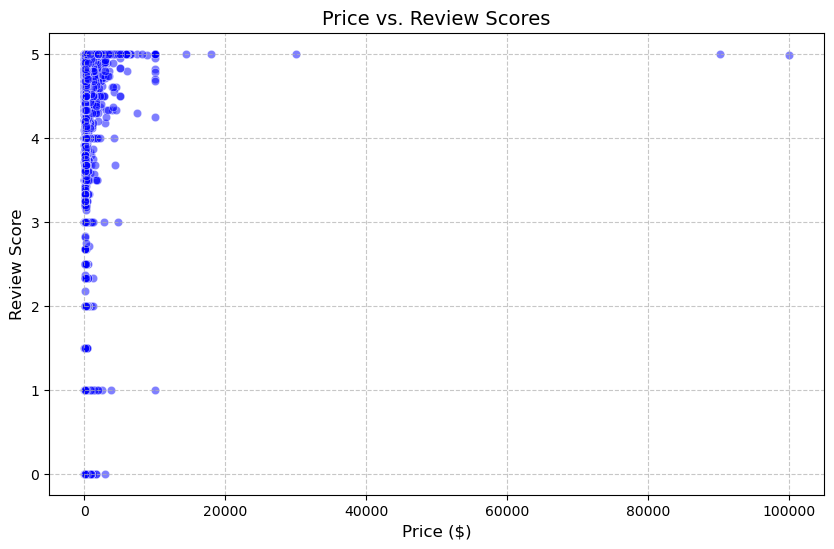

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

price_rating_corr = df[['price', 'review_scores_rating']].corr().iloc[0, 1]

print(f"Correlation between Price and Review Scores: {price_rating_corr:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['price'], y=df['review_scores_rating'], alpha=0.5, color='blue')

plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Review Score", fontsize=12)
plt.title("Price vs. Review Scores", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Superhost vs. Non-Superhost Analysis:
                   review_scores_rating  availability_30
host_is_superhost                                       
f                              4.599237        14.538740
t                              4.878834        13.907364


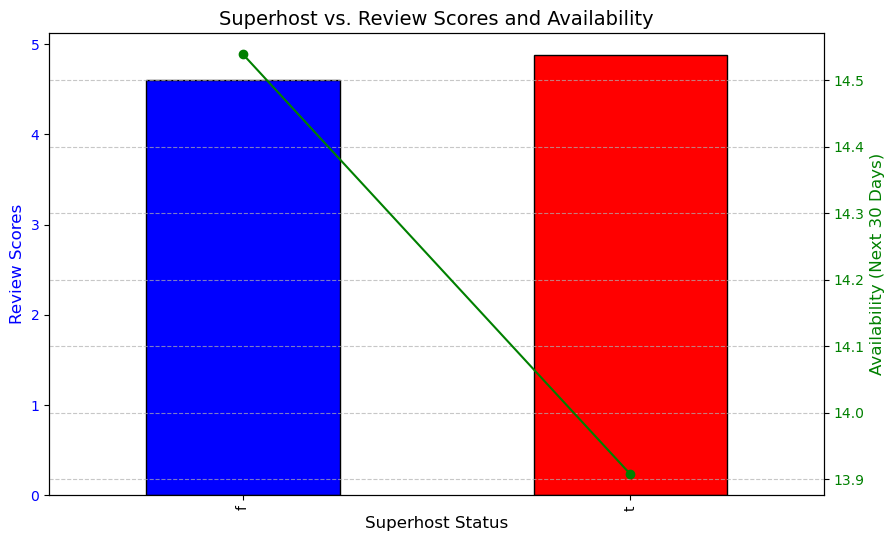

In [27]:
import matplotlib.pyplot as plt

superhost_analysis = df.groupby('host_is_superhost')[['review_scores_rating', 'availability_30']].mean()

print("Superhost vs. Non-Superhost Analysis:")
print(superhost_analysis)

fig, ax1 = plt.subplots(figsize=(10, 6))

superhost_analysis['review_scores_rating'].plot(kind='bar', color=['blue', 'red'], edgecolor='black', ax=ax1)
ax1.set_xlabel("Superhost Status", fontsize=12)
ax1.set_ylabel("Review Scores", fontsize=12, color="blue")
ax1.set_title("Superhost vs. Review Scores and Availability", fontsize=14)
ax1.tick_params(axis='y', labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(superhost_analysis.index, superhost_analysis['availability_30'], marker='o', linestyle='-', color='green', label="Availability (30 Days)")
ax2.set_ylabel("Availability (Next 30 Days)", fontsize=12, color="green")
ax2.tick_params(axis='y', labelcolor="green")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Superhost vs. Non-Superhost: Review Scores, Response Rate, Availability
                   review_scores_rating  host_response_rate  availability_30
host_is_superhost                                                           
f                              4.599237           64.034801        14.538740
t                              4.878834           96.909556        13.907364


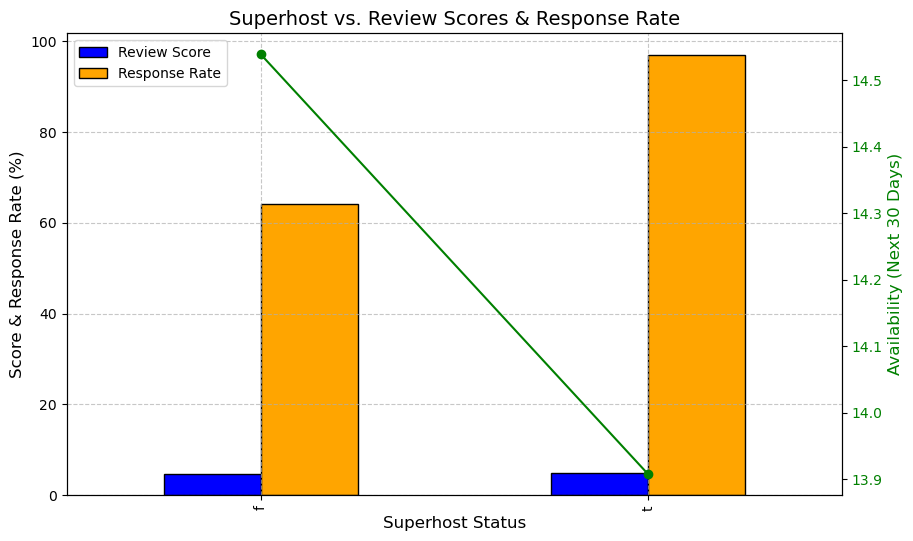

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '').replace('nan', '0').astype(float)
df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')
df['availability_30'] = pd.to_numeric(df['availability_30'], errors='coerce')

superhost_analysis = df.groupby('host_is_superhost')[['review_scores_rating', 'host_response_rate', 'availability_30']].mean()

print("Superhost vs. Non-Superhost: Review Scores, Response Rate, Availability")
print(superhost_analysis)

fig, ax1 = plt.subplots(figsize=(10, 6))

superhost_analysis[['review_scores_rating', 'host_response_rate']].plot(
    kind='bar', stacked=False, ax=ax1, color=['blue', 'orange'], edgecolor='black'
)

ax1.set_xlabel("Superhost Status", fontsize=12)
ax1.set_ylabel("Score & Response Rate (%)", fontsize=12)
ax1.set_title("Superhost vs. Review Scores & Response Rate", fontsize=14)
ax1.legend(["Review Score", "Response Rate"])
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(superhost_analysis.index, superhost_analysis['availability_30'], marker='o', linestyle='-', color='green', label="Availability (30 Days)")
ax2.set_ylabel("Availability (Next 30 Days)", fontsize=12, color="green")
ax2.tick_params(axis='y', labelcolor="green")

plt.show()

Impact of High-Quality Amenities on Review Scores:
                     False     True 
Wifi              4.791999  4.702473
Kitchen           4.618726  4.721476
Washer            4.747883  4.672119
Free parking      4.672420  4.734415
Air conditioning  4.765865  4.658947
Heating           4.716916  4.708056
TV                4.564715  4.730291
Pool              4.725658  4.616887


<Figure size 1200x600 with 0 Axes>

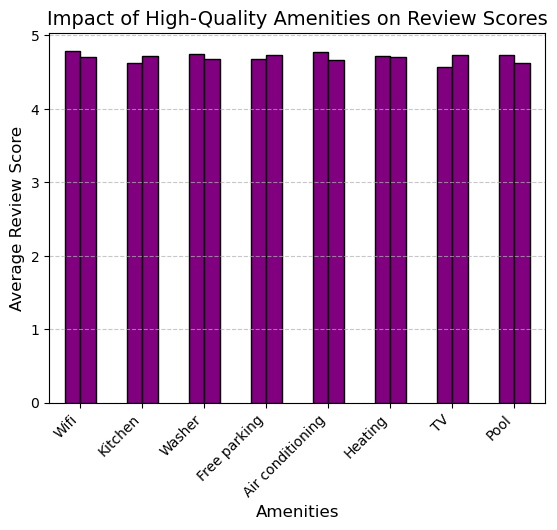

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')
high_quality_amenities = ['Wifi', 'Kitchen', 'Washer', 'Free parking', 'Air conditioning', 'Heating', 'TV', 'Pool']

for amenity in high_quality_amenities:
    df[amenity] = df['amenities'].astype(str).apply(lambda x: amenity in x)

amenities_analysis = pd.DataFrame({
    amenity: df.groupby(amenity)['review_scores_rating'].mean() for amenity in high_quality_amenities
}).T

print("Impact of High-Quality Amenities on Review Scores:")
print(amenities_analysis)

plt.figure(figsize=(12, 6))
amenities_analysis.plot(kind='bar', legend=False, color='purple', edgecolor='black')

plt.xlabel("Amenities", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)
plt.title("Impact of High-Quality Amenities on Review Scores", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlation between Minimum Nights and Availability (Next 30 Days): -0.05


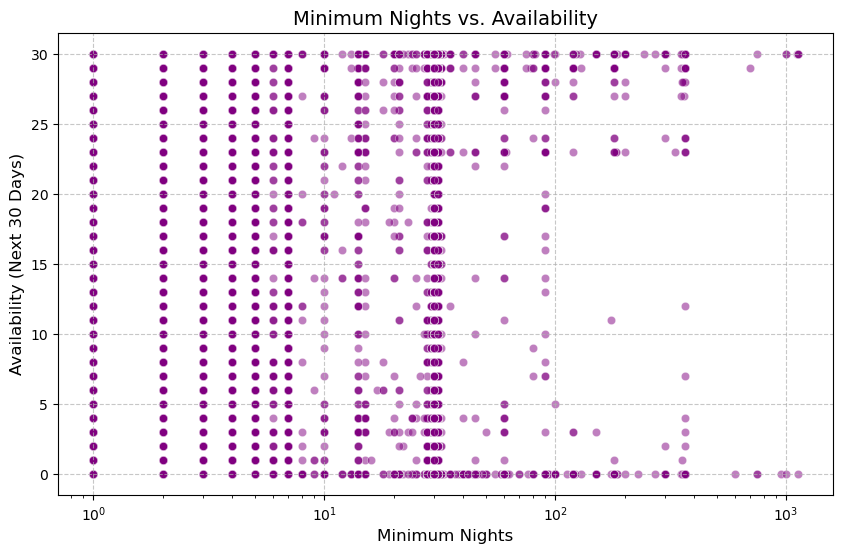

In [30]:
df['minimum_nights'] = pd.to_numeric(df['minimum_nights'], errors='coerce')
df['availability_30'] = pd.to_numeric(df['availability_30'], errors='coerce')

min_nights_availability_corr = df[['minimum_nights', 'availability_30']].corr().iloc[0, 1]
print(f"Correlation between Minimum Nights and Availability (Next 30 Days): {min_nights_availability_corr:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['minimum_nights'], y=df['availability_30'], alpha=0.5, color='purple')

plt.xlabel("Minimum Nights", fontsize=12)
plt.ylabel("Availability (Next 30 Days)", fontsize=12)
plt.title("Minimum Nights vs. Availability", fontsize=14)
plt.xscale("log")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()